In [1]:
# Cell 0 — Setup
!pip install -q kagglehub timm
from google.colab import drive
from pathlib import Path
import json, os, random, gc
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from PIL import Image
import timm
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                             cohen_kappa_score, accuracy_score)
from sklearn.utils.class_weight import compute_class_weight
from scipy import stats
from collections import Counter
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

drive.mount('/content/drive')
KOA_ROOT = Path('/content/drive/MyDrive/KOA')
NB2_OUT = KOA_ROOT / 'NB2'
NB2_OUT.mkdir(parents=True, exist_ok=True)
SAVE_DIR = KOA_ROOT / 'saved_models'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

import kagglehub
kaggle_path = kagglehub.dataset_download("shashwatwork/knee-osteoarthritis-dataset-with-severity")

def find_split_root(base):
    base = Path(base)
    for p in [base] + list(base.rglob('*')):
        if p.is_dir() and (p / 'train').is_dir():
            return p
    return base

kaggle_root = find_split_root(kaggle_path)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"Kaggle root: {kaggle_root}")

Mounted at /content/drive
Using Colab cache for faster access to the 'knee-osteoarthritis-dataset-with-severity' dataset.
Device: cuda
Kaggle root: /kaggle/input/knee-osteoarthritis-dataset-with-severity


In [2]:
# Cell 1 — Constants
SEEDS = [42, 123, 456]
BATCH_SIZE = 16
EPOCHS = 20
PATIENCE = 4
LR = 1e-4
IMG_SIZE = 224
N_CLASSES = 5

ARCHITECTURES = {
    'ConvNeXt-L': 'convnext_large',
    'EfficientNet-B0': 'efficientnet_b0',
    'DenseNet201': 'densenet201',
    'Xception': 'xception',
    'Swin-T': 'swin_tiny_patch4_window7_224',
}

LOSSES = ['CE', 'CORAL']

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [3]:
# Cell 2 — Transforms + Dataset
train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(0.5),
    T.RandomRotation(10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

class KneeDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img = Image.open(row.path).convert('RGB')
        except:
            img = Image.new('RGB', (IMG_SIZE, IMG_SIZE), (0,0,0))
        return self.transform(img), int(row.label)

In [4]:
# Cell 3 — Load Data + Splits
records = []
for split in ['train', 'val', 'test']:
    split_dir = kaggle_root / split
    if not split_dir.exists():
        continue
    for grade_dir in sorted(split_dir.iterdir()):
        if not grade_dir.is_dir():
            continue
        try:
            grade = int(grade_dir.name)
        except ValueError:
            continue
        for img_path in sorted(grade_dir.glob('*')):
            if img_path.suffix.lower() in ['.png', '.jpg', '.jpeg']:
                records.append({'path': str(img_path), 'label': grade, 'split': split})

df = pd.DataFrame(records)
train_df = df[df['split'] == 'train'].copy()
val_df = df[df['split'] == 'val'].copy()
test_df = df[df['split'] == 'test'].copy()

train_labels = train_df['label'].values
cw = compute_class_weight('balanced', classes=np.arange(N_CLASSES), y=train_labels)
class_weights_tensor = torch.tensor(cw, dtype=torch.float).to(device)

train_loader = DataLoader(KneeDataset(train_df, train_transform),
                          batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(KneeDataset(val_df, val_transform),
                        batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(KneeDataset(test_df, val_transform),
                         batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"Class weights: {cw.round(3)}")

Train: 5778 | Val: 826 | Test: 1656
Class weights: [0.506 1.105 0.762 1.527 6.68 ]


In [5]:
# Cell 4 — CORAL Loss + Ordinal Model
class CORAL(nn.Module):
    def __init__(self, num_classes, class_weights=None):
        super().__init__()
        self.num_classes = num_classes
        if class_weights is not None:
            self.register_buffer('class_weights', class_weights)
        else:
            self.class_weights = None

    def forward(self, logits, targets):
        binary_targets = (targets.unsqueeze(1) > torch.arange(self.num_classes - 1, device=targets.device)).float()
        loss = nn.functional.binary_cross_entropy_with_logits(logits, binary_targets, reduction='none')
        if self.class_weights is not None:
            weight = self.class_weights[targets].unsqueeze(1)
            loss = loss * weight
        return loss.mean()

class OrdinalModel(nn.Module):
    def __init__(self, base_name, num_classes, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(base_name, pretrained=pretrained, num_classes=0)
        self.classifier = nn.Linear(self.backbone.num_features, num_classes - 1)
    def forward(self, x):
        return self.classifier(self.backbone(x))

def ordinal_predict(logits):
    return (torch.sigmoid(logits) > 0.5).sum(dim=1).long()

In [6]:
# Cell 5 — Training Infrastructure
def train_model(model, train_loader, val_loader, criterion, ordinal=False,
                epochs=EPOCHS, patience=PATIENCE, lr=LR):
    head_kw = ['classifier', 'head', 'fc']
    head_params = [p for n, p in model.named_parameters() if any(k in n for k in head_kw)]
    backbone_params = [p for n, p in model.named_parameters() if not any(k in n for k in head_kw)]

    if head_params:
        param_groups = [{'params': backbone_params, 'lr': lr * 0.1},
                        {'params': head_params, 'lr': lr}]
    else:
        param_groups = [{'params': model.parameters(), 'lr': lr}]

    optimizer = optim.AdamW(param_groups, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2)
    scaler = torch.amp.GradScaler('cuda')
    best_val_loss = float('inf')
    counter = 0
    best_state = None

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            with torch.amp.autocast('cuda'):
                out = model(x)
                loss = criterion(out, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item() * x.size(0)
            pred = ordinal_predict(out) if ordinal else torch.argmax(out, dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)
        scheduler.step()

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                with torch.amp.autocast('cuda'):
                    out = model(x)
                    loss = criterion(out, y)
                val_loss += loss.item() * x.size(0)
                pred = ordinal_predict(out) if ordinal else torch.argmax(out, dim=1)
                val_correct += (pred == y).sum().item()
                val_total += y.size(0)

        train_acc = correct / total
        val_acc = val_correct / val_total
        val_loss_avg = val_loss / val_total
        print(f"  Epoch {epoch}/{epochs}  train_acc={train_acc:.4f}  val_acc={val_acc:.4f}  val_loss={val_loss_avg:.4f}")

        if val_loss_avg < best_val_loss:
            best_val_loss = val_loss_avg
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print(f"  Early stopping at epoch {epoch}")
                break

    if best_state:
        model.load_state_dict(best_state)
    return model

def evaluate(model, loader, ordinal=False):
    model.eval()
    all_preds, all_labels, all_logits = [], [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            with torch.amp.autocast('cuda'):
                out = model(x)
            pred = ordinal_predict(out) if ordinal else torch.argmax(out, dim=1)
            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
            all_logits.append(out.cpu())
    all_logits = torch.cat(all_logits)
    preds, labels = np.array(all_preds), np.array(all_labels)
    acc = accuracy_score(labels, preds)
    qwk = cohen_kappa_score(labels, preds, weights='quadratic')
    f1 = f1_score(labels, preds, average=None, zero_division=0)
    return acc, qwk, f1, preds, labels, all_logits

In [7]:
# Cell 6 — Run 30 Five-Class Experiments
results = {}
all_preds_data = {}

for arch_name, model_name in ARCHITECTURES.items():
    results[arch_name] = {}
    for loss_name in LOSSES:
        results[arch_name][loss_name] = {'acc': [], 'qwk': [], 'f1': [], 'preds': [], 'labels': []}
        print(f"\n{'='*60}")
        print(f"{arch_name} — {loss_name}")
        print(f"{'='*60}")

        for seed in SEEDS:
            save_path = str(SAVE_DIR / f"{arch_name}_{loss_name}_5class_seed{seed}.pth")

            if os.path.exists(save_path):
                print(f"  ✓ Loading {arch_name}_{loss_name}_seed{seed} (exists)")
                if loss_name == 'CORAL':
                    model = OrdinalModel(model_name, N_CLASSES, pretrained=False).to(device)
                else:
                    model = timm.create_model(model_name, pretrained=False, num_classes=N_CLASSES).to(device)
                model.load_state_dict(torch.load(save_path, map_location=device))
            else:
                print(f"  Training {arch_name}_{loss_name}_seed{seed}...")
                set_seed(seed)
                if loss_name == 'CORAL':
                    model = OrdinalModel(model_name, N_CLASSES).to(device)
                    criterion = CORAL(N_CLASSES, class_weights=class_weights_tensor)
                    ordinal = True
                else:
                    model = timm.create_model(model_name, pretrained=True, num_classes=N_CLASSES).to(device)
                    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
                    ordinal = False

                model = train_model(model, train_loader, val_loader, criterion, ordinal=ordinal)
                torch.save(model.state_dict(), save_path)
                print(f"  💾 Saved {save_path}")

            ordinal = loss_name == 'CORAL'
            acc, qwk, f1, preds, labels, logits = evaluate(model, test_loader, ordinal=ordinal)
            results[arch_name][loss_name]['acc'].append(acc)
            results[arch_name][loss_name]['qwk'].append(qwk)
            results[arch_name][loss_name]['f1'].append(f1.tolist())
            results[arch_name][loss_name]['preds'].append(preds.tolist())
            results[arch_name][loss_name]['labels'].append(labels.tolist())
            print(f"    acc={acc:.4f}  qwk={qwk:.4f}  KL-1 F1={f1[1]:.4f}")

            del model
            torch.cuda.empty_cache()
            gc.collect()

print("\n✓ All 30 runs complete")


ConvNeXt-L — CE
  Training ConvNeXt-L_CE_seed42...


model.safetensors:   0%|          | 0.00/791M [00:00<?, ?B/s]

  Epoch 1/20  train_acc=0.4868  val_acc=0.6199  val_loss=0.8553
  Epoch 2/20  train_acc=0.6269  val_acc=0.6550  val_loss=0.8062
  Epoch 3/20  train_acc=0.6675  val_acc=0.6017  val_loss=0.8367
  Epoch 4/20  train_acc=0.7051  val_acc=0.6804  val_loss=0.7251
  Epoch 5/20  train_acc=0.7442  val_acc=0.6586  val_loss=0.7629
  Epoch 6/20  train_acc=0.6918  val_acc=0.6525  val_loss=0.8435
  Epoch 7/20  train_acc=0.7018  val_acc=0.6574  val_loss=0.8180
  Epoch 8/20  train_acc=0.7300  val_acc=0.6102  val_loss=0.8698
  Early stopping at epoch 8
  💾 Saved /content/drive/MyDrive/KOA/saved_models/ConvNeXt-L_CE_5class_seed42.pth
    acc=0.7126  qwk=0.8633  KL-1 F1=0.3770
  Training ConvNeXt-L_CE_seed123...
  Epoch 1/20  train_acc=0.4609  val_acc=0.5751  val_loss=0.9405
  Epoch 2/20  train_acc=0.6256  val_acc=0.5944  val_loss=0.9027
  Epoch 3/20  train_acc=0.6627  val_acc=0.6550  val_loss=0.8307
  Epoch 4/20  train_acc=0.7011  val_acc=0.6695  val_loss=0.7722
  Epoch 5/20  train_acc=0.7400  val_acc=0.6

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

  Epoch 1/20  train_acc=0.2726  val_acc=0.3123  val_loss=2.1310
  Epoch 2/20  train_acc=0.3364  val_acc=0.3523  val_loss=1.8025
  Epoch 3/20  train_acc=0.3766  val_acc=0.3462  val_loss=1.8570
  Epoch 4/20  train_acc=0.3989  val_acc=0.3850  val_loss=1.7479
  Epoch 5/20  train_acc=0.4090  val_acc=0.3547  val_loss=1.7411
  Epoch 6/20  train_acc=0.4161  val_acc=0.4056  val_loss=1.6022
  Epoch 7/20  train_acc=0.4477  val_acc=0.4165  val_loss=1.5080
  Epoch 8/20  train_acc=0.4630  val_acc=0.4298  val_loss=1.5361
  Epoch 9/20  train_acc=0.4775  val_acc=0.4600  val_loss=1.4743
  Epoch 10/20  train_acc=0.5145  val_acc=0.4734  val_loss=1.3995
  Epoch 11/20  train_acc=0.5130  val_acc=0.4939  val_loss=1.3395
  Epoch 12/20  train_acc=0.5230  val_acc=0.4770  val_loss=1.3851
  Epoch 13/20  train_acc=0.5343  val_acc=0.5048  val_loss=1.3675
  Epoch 14/20  train_acc=0.5339  val_acc=0.4976  val_loss=1.3111
  Epoch 15/20  train_acc=0.5358  val_acc=0.4843  val_loss=1.3475
  Epoch 16/20  train_acc=0.5379  v

model.safetensors:   0%|          | 0.00/81.1M [00:00<?, ?B/s]

  Epoch 1/20  train_acc=0.3538  val_acc=0.4322  val_loss=1.2706
  Epoch 2/20  train_acc=0.5130  val_acc=0.5387  val_loss=1.0423
  Epoch 3/20  train_acc=0.5729  val_acc=0.5593  val_loss=0.9818
  Epoch 4/20  train_acc=0.5857  val_acc=0.5860  val_loss=0.9643
  Epoch 5/20  train_acc=0.6082  val_acc=0.5787  val_loss=0.9526
  Epoch 6/20  train_acc=0.5926  val_acc=0.5569  val_loss=0.9756
  Epoch 7/20  train_acc=0.6096  val_acc=0.5981  val_loss=0.8895
  Epoch 8/20  train_acc=0.6314  val_acc=0.6029  val_loss=0.9053
  Epoch 9/20  train_acc=0.6495  val_acc=0.6150  val_loss=0.8715
  Epoch 10/20  train_acc=0.6571  val_acc=0.5823  val_loss=0.8842
  Epoch 11/20  train_acc=0.6651  val_acc=0.6114  val_loss=0.8750
  Epoch 12/20  train_acc=0.6805  val_acc=0.6223  val_loss=0.8633
  Epoch 13/20  train_acc=0.6876  val_acc=0.6102  val_loss=0.8672
  Epoch 14/20  train_acc=0.6949  val_acc=0.6199  val_loss=0.8661
  Epoch 15/20  train_acc=0.7006  val_acc=0.6102  val_loss=0.8758
  Epoch 16/20  train_acc=0.6795  v

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

  Epoch 1/20  train_acc=0.4143  val_acc=0.4855  val_loss=1.2325
  Epoch 2/20  train_acc=0.5516  val_acc=0.6441  val_loss=0.8817
  Epoch 3/20  train_acc=0.6063  val_acc=0.5085  val_loss=0.9823
  Epoch 4/20  train_acc=0.6319  val_acc=0.6235  val_loss=0.8379
  Epoch 5/20  train_acc=0.6499  val_acc=0.6441  val_loss=0.7907
  Epoch 6/20  train_acc=0.6186  val_acc=0.6114  val_loss=0.8646
  Epoch 7/20  train_acc=0.6260  val_acc=0.6646  val_loss=0.8111
  Epoch 8/20  train_acc=0.6402  val_acc=0.6223  val_loss=0.8312
  Epoch 9/20  train_acc=0.6497  val_acc=0.6235  val_loss=0.8040
  Early stopping at epoch 9
  💾 Saved /content/drive/MyDrive/KOA/saved_models/Swin-T_CE_5class_seed42.pth
    acc=0.6679  qwk=0.8379  KL-1 F1=0.3954
  Training Swin-T_CE_seed123...
  Epoch 1/20  train_acc=0.4150  val_acc=0.5496  val_loss=1.0212
  Epoch 2/20  train_acc=0.5561  val_acc=0.5944  val_loss=0.9399
  Epoch 3/20  train_acc=0.5981  val_acc=0.6053  val_loss=0.9280
  Epoch 4/20  train_acc=0.6265  val_acc=0.6138  val

In [8]:
# Cell 7 — Results Table
def ci95(vals):
    n = len(vals)
    if n < 3:
        return np.mean(vals), np.mean(vals)
    se = np.std(vals, ddof=1) / np.sqrt(n)
    h = se * stats.t.ppf(0.975, n - 1)
    m = np.mean(vals)
    return m - h, m + h

rows = []
for arch in ARCHITECTURES:
    for loss in LOSSES:
        d = results[arch][loss]
        m_acc, s_acc = np.mean(d['acc']), np.std(d['acc'])
        m_qwk, s_qwk = np.mean(d['qwk']), np.std(d['qwk'])
        ci_l, ci_h = ci95(d['acc'])
        rows.append({
            'Architecture': arch, 'Loss': loss,
            'Accuracy': f"{m_acc:.3f}±{s_acc:.3f}",
            '95% CI': f"[{ci_l:.3f},{ci_h:.3f}]",
            'QWK': f"{m_qwk:.3f}±{s_qwk:.3f}",
        })

df_results = pd.DataFrame(rows)
print(df_results.to_string(index=False))
df_results.to_csv(str(NB2_OUT / 'nb2_results_5class.csv'), index=False)
print("\n✓ nb2_results_5class.csv")

   Architecture  Loss    Accuracy        95% CI         QWK
     ConvNeXt-L    CE 0.713±0.002 [0.706,0.720] 0.865±0.001
     ConvNeXt-L CORAL 0.681±0.006 [0.662,0.700] 0.861±0.006
EfficientNet-B0    CE 0.486±0.011 [0.452,0.521] 0.652±0.030
EfficientNet-B0 CORAL 0.601±0.011 [0.567,0.635] 0.805±0.003
    DenseNet201    CE 0.652±0.003 [0.644,0.661] 0.805±0.002
    DenseNet201 CORAL 0.618±0.012 [0.583,0.653] 0.817±0.008
       Xception    CE 0.605±0.019 [0.546,0.664] 0.748±0.013
       Xception CORAL 0.533±0.024 [0.460,0.607] 0.764±0.013
         Swin-T    CE 0.687±0.015 [0.642,0.732] 0.843±0.006
         Swin-T CORAL 0.671±0.004 [0.660,0.683] 0.844±0.002

✓ nb2_results_5class.csv


In [9]:
# Cell 8 — Per-class F1 Table
f1_rows = []
for arch in ARCHITECTURES:
    for loss in LOSSES:
        f1_all = np.array(results[arch][loss]['f1'])
        f1_mean = f1_all.mean(axis=0)
        f1_rows.append({'Architecture': arch, 'Loss': loss,
                        **{f'KL-{i}': f'{f1_mean[i]:.3f}' for i in range(5)}})

df_f1 = pd.DataFrame(f1_rows)
print(df_f1.to_string(index=False))

mean_f1_per_grade = {f'KL-{i}': np.mean([float(r[f'KL-{i}']) for r in f1_rows]) for i in range(5)}
print(f"\nMean F1 across all configs: {mean_f1_per_grade}")
df_f1.to_csv(str(NB2_OUT / 'nb2_f1_table.csv'), index=False)
print("✓ nb2_f1_table.csv")

   Architecture  Loss  KL-0  KL-1  KL-2  KL-3  KL-4
     ConvNeXt-L    CE 0.808 0.418 0.712 0.819 0.849
     ConvNeXt-L CORAL 0.763 0.432 0.693 0.817 0.864
EfficientNet-B0    CE 0.593 0.259 0.448 0.586 0.614
EfficientNet-B0 CORAL 0.707 0.393 0.549 0.738 0.786
    DenseNet201    CE 0.755 0.340 0.607 0.800 0.839
    DenseNet201 CORAL 0.697 0.365 0.609 0.802 0.843
       Xception    CE 0.721 0.221 0.548 0.735 0.798
       Xception CORAL 0.594 0.350 0.536 0.703 0.778
         Swin-T    CE 0.794 0.380 0.643 0.821 0.859
         Swin-T CORAL 0.774 0.397 0.630 0.821 0.860

Mean F1 across all configs: {'KL-0': np.float64(0.7206), 'KL-1': np.float64(0.3555), 'KL-2': np.float64(0.5974999999999999), 'KL-3': np.float64(0.7642), 'KL-4': np.float64(0.8089999999999999)}
✓ nb2_f1_table.csv


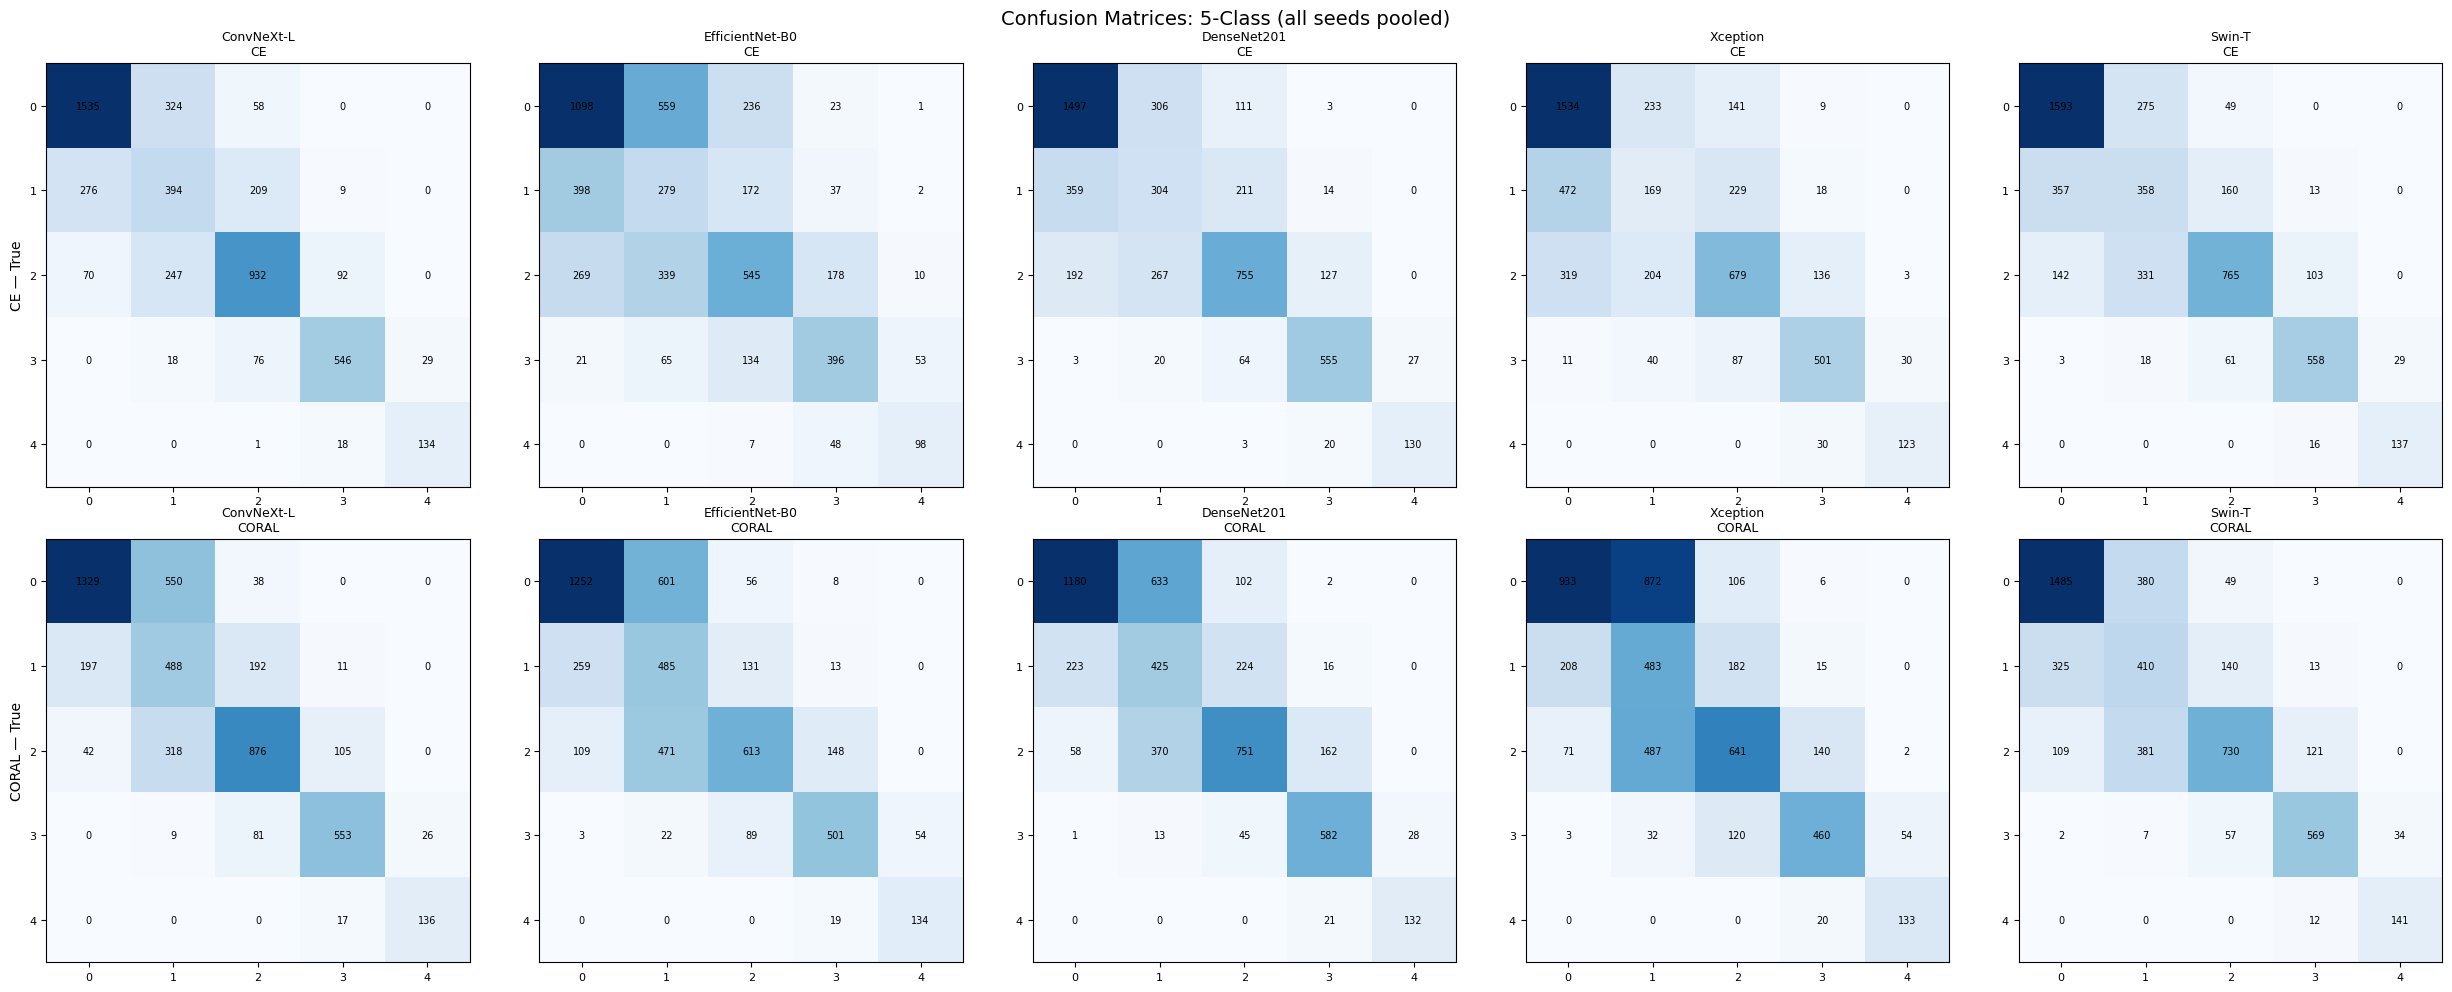

✓ nb2_confusion_matrices.png


In [10]:
# Cell 9 — Confusion Matrices
fig, axes = plt.subplots(2, 5, figsize=(25, 10))
for idx, (arch, model_name) in enumerate(ARCHITECTURES.items()):
    for row, loss in enumerate(LOSSES):
        all_p = np.concatenate([results[arch][loss]['preds'][s] for s in range(len(SEEDS))])
        all_l = np.concatenate([results[arch][loss]['labels'][s] for s in range(len(SEEDS))])
        cm = confusion_matrix(all_l, all_p, labels=range(5))
        ax = axes[row, idx]
        im = ax.imshow(cm, cmap='Blues', interpolation='nearest')
        ax.set_xticks(range(5)); ax.set_yticks(range(5))
        ax.set_xticklabels([f'{i}' for i in range(5)], fontsize=8)
        ax.set_yticklabels([f'{i}' for i in range(5)], fontsize=8)
        ax.set_title(f'{arch}\n{loss}', fontsize=9)
        for i in range(5):
            for j in range(5):
                ax.text(j, i, str(cm[i,j]), ha='center', va='center', fontsize=7)

axes[0,0].set_ylabel('CE — True')
axes[1,0].set_ylabel('CORAL — True')
plt.suptitle('Confusion Matrices: 5-Class (all seeds pooled)', fontsize=14)
plt.tight_layout()
fig.savefig(str(NB2_OUT / 'nb2_confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✓ nb2_confusion_matrices.png")

Mean adjacent-error rate: 85.2%
95% CI: [82.5%, 87.9%]
Mean QWK: 0.800 ± 0.063


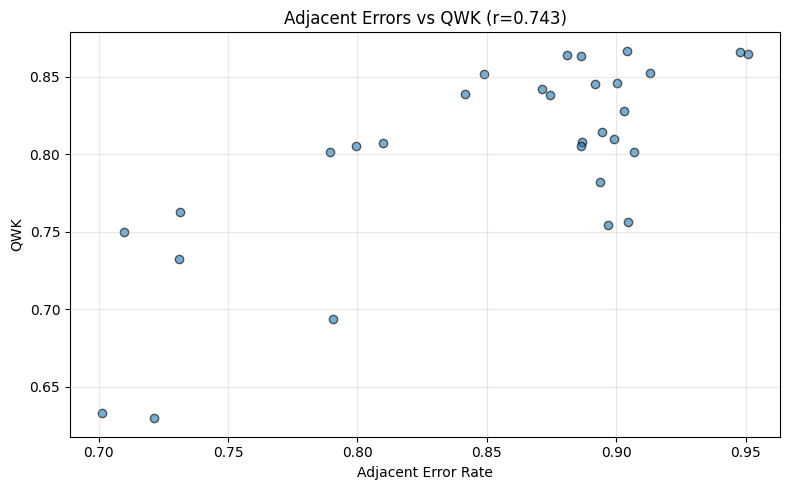

✓ nb2_adjacent_errors.png


In [11]:
# Cell 10 — Adjacent Error Analysis
def adjacent_error_rate(preds, labels):
    cm = confusion_matrix(labels, preds, labels=range(5))
    total_err = np.sum(cm) - np.trace(cm)
    if total_err == 0:
        return 0.0
    adj_err = sum(cm[i, i+1] + cm[i+1, i] for i in range(4))
    return adj_err / total_err

adj_rates, qwk_vals = [], []
for arch in ARCHITECTURES:
    for loss in LOSSES:
        for s in range(len(SEEDS)):
            p = np.array(results[arch][loss]['preds'][s])
            l = np.array(results[arch][loss]['labels'][s])
            adj_rates.append(adjacent_error_rate(p, l))
            qwk_vals.append(results[arch][loss]['qwk'][s])

print(f"Mean adjacent-error rate: {np.mean(adj_rates)*100:.1f}%")
print(f"95% CI: [{ci95(adj_rates)[0]*100:.1f}%, {ci95(adj_rates)[1]*100:.1f}%]")
print(f"Mean QWK: {np.mean(qwk_vals):.3f} ± {np.std(qwk_vals):.3f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(adj_rates, qwk_vals, alpha=0.6, edgecolor='black')
ax.set_xlabel('Adjacent Error Rate')
ax.set_ylabel('QWK')
ax.set_title(f'Adjacent Errors vs QWK (r={np.corrcoef(adj_rates, qwk_vals)[0,1]:.3f})')
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(str(NB2_OUT / 'nb2_adjacent_errors.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✓ nb2_adjacent_errors.png")

In [12]:
# Cell 11 — Ceiling Hypothesis Test
all_accs = []
for arch in ARCHITECTURES:
    for loss in LOSSES:
        all_accs.extend(results[arch][loss]['acc'])

t_stat, p_value = stats.ttest_1samp(all_accs, 0.75)
p_one_sided = p_value / 2 if t_stat < 0 else 1 - p_value / 2

best_acc = max(all_accs)
mean_acc = np.mean(all_accs)
std_acc = np.std(all_accs)
arch_means = {arch: np.mean([np.mean(results[arch][l]['acc']) for l in LOSSES]) for arch in ARCHITECTURES}
spread = max(arch_means.values()) - min(arch_means.values())

print(f"Mean accuracy (all 30 runs): {mean_acc:.4f} ± {std_acc:.4f}")
print(f"Best single run: {best_acc:.4f}")
print(f"Architecture spread: {spread*100:.1f}pp")
print(f"\nt-test H₀(μ ≥ 0.75): t={t_stat:.3f}, p={p_one_sided:.6f}")
if p_one_sided < 0.05:
    print("→ REJECT H₀: ceiling confirmed below 75%")
else:
    print("→ FAIL to reject H₀")

from scipy.stats import f_oneway
ce_accs_by_arch = [results[arch]['CE']['acc'] for arch in ARCHITECTURES]
F, p_anova = f_oneway(*ce_accs_by_arch)
print(f"\nANOVA (CE across architectures): F={F:.3f}, p={p_anova:.4f}")

Mean accuracy (all 30 runs): 0.6247 ± 0.0691
Best single run: 0.7156
Architecture spread: 15.3pp

t-test H₀(μ ≥ 0.75): t=-9.758, p=0.000000
→ REJECT H₀: ceiling confirmed below 75%

ANOVA (CE across architectures): F=108.360, p=0.0000


In [13]:
# Cell 12 — Save Probabilities for NB4
best_arch, best_loss, best_seed_idx = None, None, None
best_val = 0
for arch in ARCHITECTURES:
    for loss in LOSSES:
        for s_idx, acc in enumerate(results[arch][loss]['acc']):
            if acc > best_val:
                best_val = acc
                best_arch, best_loss, best_seed_idx = arch, loss, s_idx

print(f"Best model: {best_arch} {best_loss} seed={SEEDS[best_seed_idx]} (acc={best_val:.4f})")

model_path = str(SAVE_DIR / f"{best_arch}_{best_loss}_5class_seed{SEEDS[best_seed_idx]}.pth")
model_name = ARCHITECTURES[best_arch]
if best_loss == 'CORAL':
    model = OrdinalModel(model_name, N_CLASSES, pretrained=False).to(device)
else:
    model = timm.create_model(model_name, pretrained=False, num_classes=N_CLASSES).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

train_loader_noshuf = DataLoader(KneeDataset(train_df, val_transform),
                                  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
all_probs, all_labels = [], []
with torch.no_grad():
    for x, y in train_loader_noshuf:
        x = x.to(device)
        with torch.amp.autocast('cuda'):
            out = model(x)
        if best_loss == 'CORAL':
            probs = torch.sigmoid(out).cpu().numpy()
            full_probs = np.zeros((probs.shape[0], N_CLASSES))
            for i in range(N_CLASSES):
                if i == 0:
                    full_probs[:, i] = 1 - probs[:, 0]
                elif i < N_CLASSES - 1:
                    full_probs[:, i] = probs[:, i-1] - probs[:, i]
                else:
                    full_probs[:, i] = probs[:, i-1]
            full_probs = np.clip(full_probs, 0, 1)
            row_sums = full_probs.sum(axis=1, keepdims=True)
            row_sums[row_sums == 0] = 1
            full_probs = full_probs / row_sums
            all_probs.append(full_probs)
        else:
            all_probs.append(torch.softmax(out, dim=1).cpu().numpy())
        all_labels.extend(y.numpy())

probs_np = np.concatenate(all_probs)
labels_np = np.array(all_labels)
np.save(str(NB2_OUT / 'nb2_probabilities.npy'), probs_np)
np.save(str(NB2_OUT / 'nb2_labels.npy'), labels_np)
print(f"✓ Probabilities: {probs_np.shape}, Labels: {labels_np.shape}")

del model
torch.cuda.empty_cache()
gc.collect()

Best model: ConvNeXt-L CE seed=456 (acc=0.7156)
✓ Probabilities: (5778, 5), Labels: (5778,)


17

In [14]:
# Cell 13 — Save Results
nb2_results = {
    'results': {},
    'mean_accuracy': float(mean_acc),
    'std_accuracy': float(std_acc),
    'best_model': f"{best_arch}_{best_loss}_seed{SEEDS[best_seed_idx]}",
    'best_accuracy': float(best_val),
    'ceiling_ttest_p': float(p_one_sided),
    'anova_p': float(p_anova),
    'arch_spread_pp': float(spread * 100),
    'adjacent_error_mean': float(np.mean(adj_rates)),
}
for arch in ARCHITECTURES:
    nb2_results['results'][arch] = {}
    for loss in LOSSES:
        nb2_results['results'][arch][loss] = {
            'acc': results[arch][loss]['acc'],
            'qwk': results[arch][loss]['qwk'],
            'f1': results[arch][loss]['f1'],
        }

with open(str(NB2_OUT / 'nb2_results.json'), 'w') as f:
    json.dump(nb2_results, f, indent=2)

for fn in ['nb2_results.json', 'nb2_results_5class.csv', 'nb2_f1_table.csv',
           'nb2_confusion_matrices.png', 'nb2_adjacent_errors.png',
           'nb2_probabilities.npy', 'nb2_labels.npy']:
    print(f"  {'✓' if (NB2_OUT / fn).exists() else '✗'} {fn}")

  ✓ nb2_results.json
  ✓ nb2_results_5class.csv
  ✓ nb2_f1_table.csv
  ✓ nb2_confusion_matrices.png
  ✓ nb2_adjacent_errors.png
  ✓ nb2_probabilities.npy
  ✓ nb2_labels.npy
